## Daily Weather in India, 2000-2024
#### Retrieved from Kaggle: https://www.kaggle.com/datasets/developerghost/climate-in-india-daily-weather-data-2000-2024/data

In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
path = r'C:\Users\artoe\Documents\DataAnalytics\projects\india weather'

In [4]:
df = pd.read_csv(os.path.join(path, 'data', 'india_2000_2024_daily_weather.csv'), index_col = False)

### Data Description
##### (copied from Kaggle)
##### city – Name of the Indian city
##### date – Daily timestamp (YYYY-MM-DD)
##### temperature_2m_max (°C) – Maximum air temperature at 2 meters height
##### temperature_2m_min (°C) – Minimum air temperature at 2 meters height
##### apparent_temperature_max (°C) – Feels-like max temperature considering humidity & wind
##### apparent_temperature_min (°C) – Feels-like min temperature
##### precipitation_sum (mm) – Total daily precipitation
##### rain_sum (mm) – Total daily rainfall
##### weather_code – WMO weather interpretation code
##### wind_speed_10m_max (km/h) – Max wind speed at 10m height
##### wind_gusts_10m_max (km/h) – Max wind gusts at 10m
##### wind_direction_10m_dominant (°) – Dominant wind direction in degrees

In [6]:
df.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
0,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0.0,0,10.9,13.3,58
1,Delhi,2000-01-02,20.0,5.5,18.9,3.4,0.0,0.0,3,9.5,14.8,326
2,Delhi,2000-01-03,20.1,6.3,18.2,4.3,0.0,0.0,0,10.0,23.8,309
3,Delhi,2000-01-04,19.8,6.4,18.5,4.2,0.0,0.0,0,8.6,18.7,311
4,Delhi,2000-01-05,19.4,5.3,17.7,3.2,0.0,0.0,0,9.4,20.2,322


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91320 entries, 0 to 91319
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   city                         91320 non-null  object 
 1   date                         91320 non-null  object 
 2   temperature_2m_max           91320 non-null  float64
 3   temperature_2m_min           91320 non-null  float64
 4   apparent_temperature_max     91320 non-null  float64
 5   apparent_temperature_min     91320 non-null  float64
 6   precipitation_sum            91320 non-null  float64
 7   rain_sum                     91320 non-null  float64
 8   weather_code                 91320 non-null  int64  
 9   wind_speed_10m_max           91320 non-null  float64
 10  wind_gusts_10m_max           91320 non-null  float64
 11  wind_direction_10m_dominant  91320 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 8.4+ MB


In [8]:
df.dtypes

city                            object
date                            object
temperature_2m_max             float64
temperature_2m_min             float64
apparent_temperature_max       float64
apparent_temperature_min       float64
precipitation_sum              float64
rain_sum                       float64
weather_code                     int64
wind_speed_10m_max             float64
wind_gusts_10m_max             float64
wind_direction_10m_dominant      int64
dtype: object

In [9]:
#which cities are represented in the data
df['city'].value_counts()

city
Delhi        9132
Mumbai       9132
Kolkata      9132
Chennai      9132
Bangalore    9132
Hyderabad    9132
Ahmedabad    9132
Pune         9132
Jaipur       9132
Lucknow      9132
Name: count, dtype: int64

### Checking data for nulls, duplicates and mixed types

#### Nulls

In [12]:
nulls = df.isnull().sum()

In [13]:
print (nulls[nulls > 0].sort_values(ascending=False))

Series([], dtype: int64)


In [14]:
#there are no nulls

#### Duplicates

In [16]:
df.duplicated().sum()

0

In [17]:
#there are no duplicates

#### Mixed types

In [19]:
for col in df.columns.tolist():
  weird = (df[[col]].map(type) != df[[col]].iloc[0].apply(type)).any(axis = 1)
  if len (df[weird]) > 0:
    print (col)

else:
    print ('there are no mixed-type columns')

there are no mixed-type columns


### Create new columns for further analysis

#### Check the weather code column
##### WMO interpretation codes

In [22]:
df['weather_code'].value_counts()

weather_code
3     21527
0     15544
51    12403
63     8483
1      8215
2      8031
61     6826
53     6647
55     2454
65     1190
Name: count, dtype: int64

#### Create a column for text descriptions of each WMO weather code (taken from https://www.nodc.noaa.gov/archive/arc0021/0002199/1.1/data/0-data/HTML/WMO-CODE/WMO4677.HTM)

In [24]:
df.loc[df['weather_code'] == 3, ['wmo_description']] = "Clouds generally forming or developing"

In [25]:
df.loc[df['weather_code'] == 0, ['wmo_description']] = "Cloud development not observed or not observable"

In [26]:
df.loc[df['weather_code'] == 51, ['wmo_description']] = "Drizzle, not freezing, continuous, slight at time of observation"

In [27]:
df.loc[df['weather_code'] == 63, ['wmo_description']] = "Rain, not freezing, continuous, moderate at time of observation"

In [28]:
df.loc[df['weather_code'] == 1, ['wmo_description']] = "Clouds generally dissolving or becoming less developed"

In [29]:
df.loc[df['weather_code'] == 2, ['wmo_description']] = "State of sky on the whole unchanged"

In [30]:
df.loc[df['weather_code'] == 61, ['wmo_description']] = "Rain, not freezing, continuous, slight at time of observation"

In [31]:
df.loc[df['weather_code'] == 53, ['wmo_description']] = "Drizzle, not freezing, continuous, moderate at time of observation"

In [32]:
df.loc[df['weather_code'] == 55, ['wmo_description']] = "Drizzle, not freezing, continuous, heavy (dense) at time of observation"

In [33]:
df.loc[df['weather_code'] == 65, ['wmo_description']] = "Rain, not freezing, continuous, heavy at time of observation"

##### It can be assumed that, among these codes, higher numbers = more precipitation.

In [35]:
df.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,wmo_description
0,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0.0,0,10.9,13.3,58,Cloud development not observed or not observable
1,Delhi,2000-01-02,20.0,5.5,18.9,3.4,0.0,0.0,3,9.5,14.8,326,Clouds generally forming or developing
2,Delhi,2000-01-03,20.1,6.3,18.2,4.3,0.0,0.0,0,10.0,23.8,309,Cloud development not observed or not observable
3,Delhi,2000-01-04,19.8,6.4,18.5,4.2,0.0,0.0,0,8.6,18.7,311,Cloud development not observed or not observable
4,Delhi,2000-01-05,19.4,5.3,17.7,3.2,0.0,0.0,0,9.4,20.2,322,Cloud development not observed or not observable


#### Mean temperature and mean apparent temperature

In [37]:
#creating new column for mean temperature
df['temperature_2m_mean'] =  df[['temperature_2m_max', 'temperature_2m_min']].mean(axis=1)

In [38]:
#creating new column for mean apparent temperature
df['apparent_temperature_mean'] =  df[['apparent_temperature_max', 'apparent_temperature_min']].mean(axis=1)

##### Month and Year columns

In [40]:
#we first need to change the date column to datetime format
df['date'] = pd.to_datetime(df['date'])

In [41]:
df['year'], df['month'] = df['date'].dt.year, df['date'].dt.month

In [42]:
df[['date', 'year', 'month',]].head()

,date,year,month
0,2000-01-01,2000,1
1,2000-01-02,2000,1
2,2000-01-03,2000,1
3,2000-01-04,2000,1
4,2000-01-05,2000,1


In [43]:
df[['date', 'year', 'month',]].tail()

,date,year,month
91315,2024-12-27,2024,12
91316,2024-12-28,2024,12
91317,2024-12-29,2024,12
91318,2024-12-30,2024,12
91319,2024-12-31,2024,12


In [44]:
df.dtypes

city                                   object
date                           datetime64[ns]
temperature_2m_max                    float64
temperature_2m_min                    float64
apparent_temperature_max              float64
apparent_temperature_min              float64
precipitation_sum                     float64
rain_sum                              float64
weather_code                            int64
wind_speed_10m_max                    float64
wind_gusts_10m_max                    float64
wind_direction_10m_dominant             int64
wmo_description                        object
temperature_2m_mean                   float64
apparent_temperature_mean             float64
year                                    int32
month                                   int32
dtype: object

In [45]:
#creating a column with distinct values for each month of each year
df['month_year'] = df['month'].astype(str) + '-' + df['year'].astype(str)

In [46]:
#aggregating temperature values by month for easier analysis and visualization
df['min_temp_monthly_avg'] = df.groupby(['month_year','city'])['temperature_2m_min'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_15404\705749205.py:2: FutureWarning: The provided callable <function mean at 0x00000207027098A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['min_temp_monthly_avg'] = df.groupby(['month_year','city'])['temperature_2m_min'].transform(np.mean)


In [47]:
df['max_temp_monthly_avg'] = df.groupby(['month_year','city'])['temperature_2m_max'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_15404\3768048779.py:1: FutureWarning: The provided callable <function mean at 0x00000207027098A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['max_temp_monthly_avg'] = df.groupby(['month_year','city'])['temperature_2m_max'].transform(np.mean)


In [48]:
df['mean_temp_monthly_avg'] = df.groupby(['month_year','city'])['temperature_2m_mean'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_15404\2451772526.py:1: FutureWarning: The provided callable <function mean at 0x00000207027098A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['mean_temp_monthly_avg'] = df.groupby(['month_year','city'])['temperature_2m_mean'].transform(np.mean)


In [49]:
df['apparent_min_temp_monthly_avg'] = df.groupby(['month_year','city'])['apparent_temperature_min'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_15404\2998996585.py:1: FutureWarning: The provided callable <function mean at 0x00000207027098A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['apparent_min_temp_monthly_avg'] = df.groupby(['month_year','city'])['apparent_temperature_min'].transform(np.mean)


In [50]:
df['apparent_max_temp_monthly_avg'] = df.groupby(['month_year','city'])['apparent_temperature_max'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_15404\2684754615.py:1: FutureWarning: The provided callable <function mean at 0x00000207027098A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['apparent_max_temp_monthly_avg'] = df.groupby(['month_year','city'])['apparent_temperature_max'].transform(np.mean)


In [51]:
df['apparent_mean_temp_monthly_avg'] = df.groupby(['month_year','city'])['apparent_temperature_mean'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_15404\3522413497.py:1: FutureWarning: The provided callable <function mean at 0x00000207027098A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['apparent_mean_temp_monthly_avg'] = df.groupby(['month_year','city'])['apparent_temperature_mean'].transform(np.mean)


In [52]:
df['precipitation_monthly_avg'] = df.groupby(['month_year','city'])['precipitation_sum'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_15404\1971413006.py:1: FutureWarning: The provided callable <function mean at 0x00000207027098A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['precipitation_monthly_avg'] = df.groupby(['month_year','city'])['precipitation_sum'].transform(np.mean)


In [53]:
df['rain_monthly_avg'] = df.groupby(['month_year','city'])['rain_sum'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_15404\1410937256.py:1: FutureWarning: The provided callable <function mean at 0x00000207027098A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['rain_monthly_avg'] = df.groupby(['month_year','city'])['rain_sum'].transform(np.mean)


In [54]:
df['max_wind_monthly_avg'] = df.groupby(['month_year','city'])['wind_speed_10m_max'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_15404\1874221016.py:1: FutureWarning: The provided callable <function mean at 0x00000207027098A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['max_wind_monthly_avg'] = df.groupby(['month_year','city'])['wind_speed_10m_max'].transform(np.mean)


In [55]:
df['max_windgusts_monthly_avg'] = df.groupby(['month_year','city'])['wind_gusts_10m_max'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_15404\872905039.py:1: FutureWarning: The provided callable <function mean at 0x00000207027098A0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['max_windgusts_monthly_avg'] = df.groupby(['month_year','city'])['wind_gusts_10m_max'].transform(np.mean)


In [56]:
df.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,...,min_temp_monthly_avg,max_temp_monthly_avg,mean_temp_monthly_avg,apparent_min_temp_monthly_avg,apparent_max_temp_monthly_avg,apparent_mean_temp_monthly_avg,precipitation_monthly_avg,rain_monthly_avg,max_wind_monthly_avg,max_windgusts_monthly_avg
0,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0.0,0,10.9,...,8.235484,20.06129,14.148387,5.990323,18.154839,12.072581,1.345161,1.345161,14.067742,27.874194
1,Delhi,2000-01-02,20.0,5.5,18.9,3.4,0.0,0.0,3,9.5,...,8.235484,20.06129,14.148387,5.990323,18.154839,12.072581,1.345161,1.345161,14.067742,27.874194
2,Delhi,2000-01-03,20.1,6.3,18.2,4.3,0.0,0.0,0,10.0,...,8.235484,20.06129,14.148387,5.990323,18.154839,12.072581,1.345161,1.345161,14.067742,27.874194
3,Delhi,2000-01-04,19.8,6.4,18.5,4.2,0.0,0.0,0,8.6,...,8.235484,20.06129,14.148387,5.990323,18.154839,12.072581,1.345161,1.345161,14.067742,27.874194
4,Delhi,2000-01-05,19.4,5.3,17.7,3.2,0.0,0.0,0,9.4,...,8.235484,20.06129,14.148387,5.990323,18.154839,12.072581,1.345161,1.345161,14.067742,27.874194


#### It would not make sense to use aggregate values for wind direction, as it changes so frequently. We will use this column when performing analysis of individual years.

In [58]:
df['wind_direction_10m_dominant'].value_counts(ascending=False)

wind_direction_10m_dominant
278    530
280    527
284    526
277    521
267    520
      ... 
151    119
146    113
360    108
152    107
0       84
Name: count, Length: 361, dtype: int64

In [59]:
#export updated data-set to pkl
df.to_pickle(os.path.join(path, 'data', 'daily_weather_updated.pkl'))

### Descriptive Statistics for whole data set

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91320 entries, 0 to 91319
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   city                            91320 non-null  object        
 1   date                            91320 non-null  datetime64[ns]
 2   temperature_2m_max              91320 non-null  float64       
 3   temperature_2m_min              91320 non-null  float64       
 4   apparent_temperature_max        91320 non-null  float64       
 5   apparent_temperature_min        91320 non-null  float64       
 6   precipitation_sum               91320 non-null  float64       
 7   rain_sum                        91320 non-null  float64       
 8   weather_code                    91320 non-null  int64         
 9   wind_speed_10m_max              91320 non-null  float64       
 10  wind_gusts_10m_max              91320 non-null  float64       
 11  wi

In [62]:
df.describe()

,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,...,min_temp_monthly_avg,max_temp_monthly_avg,mean_temp_monthly_avg,apparent_min_temp_monthly_avg,apparent_max_temp_monthly_avg,apparent_mean_temp_monthly_avg,precipitation_monthly_avg,rain_monthly_avg,max_wind_monthly_avg,max_windgusts_monthly_avg
count,91320,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,...,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000,91320.000000
mean,2012-07-01 12:00:00,30.900903,21.129450,33.058268,22.863710,3.092751,3.092751,24.494492,15.523795,32.176491,...,21.129450,30.900903,26.015177,22.863710,33.058268,27.960989,3.092751,3.092751,15.523795,32.176491
min,2000-01-01 00:00:00,12.300000,1.700000,10.200000,-1.100000,0.000000,0.000000,0.000000,3.600000,10.400000,...,6.012903,17.461290,11.737097,3.929032,16.216129,10.337097,0.000000,0.000000,7.509677,17.432258
25%,2006-04-01 18:00:00,27.800000,18.000000,29.200000,18.000000,0.000000,0.000000,1.000000,11.500000,25.200000,...,17.996774,28.048387,23.361290,18.022581,29.435484,24.074138,0.061290,0.061290,12.685714,27.416129
50%,2012-07-01 12:00:00,30.700000,22.100000,33.600000,24.000000,0.000000,0.000000,3.000000,14.800000,31.000000,...,21.966667,30.812903,26.444828,23.916129,33.587097,28.608333,0.830000,0.830000,15.036667,31.470968
75%,2018-10-01 06:00:00,33.800000,25.300000,37.600000,29.100000,1.700000,1.700000,53.000000,18.700000,37.800000,...,25.332258,33.409677,29.003333,29.090323,37.370968,33.027419,4.396667,4.396667,18.056667,36.074194
max,2024-12-31 00:00:00,46.400000,34.400000,49.400000,37.800000,339.900000,339.900000,65.000000,68.900000,142.900000,...,30.877419,42.835484,35.930000,34.860000,43.943333,38.560000,39.100000,39.100000,28.300000,57.170968
std,NaN,4.770039,5.291931,5.988028,7.331756,9.164448,9.164448,27.267100,5.205461,9.576481,...,5.025937,4.369616,4.376344,6.971706,5.522707,6.050762,4.818558,4.818558,3.607767,6.704284


In [63]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,91320,2012-07-01 12:00:00,2000-01-01 00:00:00,2006-04-01 18:00:00,2012-07-01 12:00:00,2018-10-01 06:00:00,2024-12-31 00:00:00,NaN
temperature_2m_max,91320.0,30.900903,12.3,27.8,30.7,33.8,46.4,4.770039
temperature_2m_min,91320.0,21.12945,1.7,18.0,22.1,25.3,34.4,5.291931
apparent_temperature_max,91320.0,33.058268,10.2,29.2,33.6,37.6,49.4,5.988028
apparent_temperature_min,91320.0,22.86371,-1.1,18.0,24.0,29.1,37.8,7.331756
precipitation_sum,91320.0,3.092751,0.0,0.0,0.0,1.7,339.9,9.164448
rain_sum,91320.0,3.092751,0.0,0.0,0.0,1.7,339.9,9.164448
weather_code,91320.0,24.494492,0.0,1.0,3.0,53.0,65.0,27.2671
wind_speed_10m_max,91320.0,15.523795,3.6,11.5,14.8,18.7,68.9,5.205461
wind_gusts_10m_max,91320.0,32.176491,10.4,25.2,31.0,37.8,142.9,9.576481


### Descriptive Statistics by year
#### Average of all 10 Indian cities

In [65]:
descriptive_yearly = df.groupby(df['date'].dt.year)[['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean', 'precipitation_sum', 'rain_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max']].describe()

In [66]:
descriptive_yearly.T

date                             2000         2001         2002         2003  \
temperature_2m_max count  3660.000000  3650.000000  3650.000000  3650.000000   
                   mean     30.725137    30.748329    31.334548    30.821260   
                   std       4.657856     4.445292     4.984440     5.020647   
                   min      15.700000    15.700000    12.300000    12.500000   
                   25%      27.700000    27.700000    27.900000    27.800000   
...                               ...          ...          ...          ...   
wind_gusts_10m_max min      12.600000    11.900000    13.000000    12.200000   
                   25%      24.500000    24.500000    25.600000    25.200000   
                   50%      30.200000    29.900000    31.000000    30.600000   
                   75%      36.400000    36.400000    37.700000    36.700000   
                   max      73.800000    73.800000    75.200000    68.400000   

date                             2004         2005         2006         2007  \
temperature_2m_max count  3660.000000  3650.000000  3650.000000  3650.000000   
                   mean     30.899016    30.768904    31.066932    30.843945   
                   std       4.815539     4.897169     4.275544     4.581731   
                   min      15.400000    15.800000    18.100000    15.400000   
                   25%      27.800000    27.500000    28.100000    27.800000   
...                               ...          ...          ...          ...   
wind_gusts_10m_max min      12.200000    12.600000    13.000000    12.200000   
                   25%      25.200000    25.200000    24.800000    24.800000   
                   50%      31.000000    30.200000    30.200000    30.200000   
                   75%      37.400000    36.400000    36.700000    36.400000   
                   max      79.200000    78.500000    77.400000    78.500000   

date                             2008         2009  ...         2015  \
temperature_2m_max count  3660.000000  3650.000000  ...  3650.000000   
                   mean     30.584016    31.586411  ...    30.916247   
                   std       4.351007     4.690844  ...     4.715447   
                   min      16.700000    18.700000  ...    15.600000   
                   25%      27.800000    28.100000  ...    28.000000   
...                               ...          ...  ...          ...   
wind_gusts_10m_max min      11.500000    12.200000  ...    13.300000   
                   25%      24.500000    24.800000  ...    24.500000   
                   50%      29.500000    30.600000  ...    29.900000   
                   75%      36.000000    37.400000  ...    36.000000   
                   max      83.500000   104.400000  ...    81.000000   

date                             2016         2017         2018         2019  \
temperature_2m_max count  3660.000000  3650.000000  3650.000000  3650.000000   
                   mean     31.078197    30.982356    31.039288    30.715068   
                   std       4.528924     4.716630     4.575050     5.106840   
                   min      14.700000    16.000000    16.600000    12.800000   
                   25%      28.000000    28.000000    28.100000    27.700000   
...                               ...          ...          ...          ...   
wind_gusts_10m_max min      11.900000    13.300000    11.500000    12.600000   
                   25%      24.500000    27.000000    27.000000    27.000000   
                   50%      29.500000    33.500000    33.100000    33.500000   
                   75%      35.600000    41.000000    40.700000    41.000000   
                   max     114.800000    77.000000    80.300000    81.400000   

date                             2020         2021         2022         2023  \
temperature_2m_max count  3660.000000  3650.000000  3650.000000  3650.000000   
                   mean     30.492787    30.645836    30.992795    31.256329   
            

### Identify Minimum and Maximum Values

In [68]:
#minimum temperature
print(df[['date', 'city', 'temperature_2m_min']].loc[df['temperature_2m_min']==df['temperature_2m_min'].min(),:])

            date     city  temperature_2m_min
89491 2019-12-30  Lucknow                 1.7


The lowest minimum daily temperature was 1.7°C, recorded in Lucknow, on December 30, 2019.

In [70]:
#maximum temperature
print(df[['date', 'city', 'temperature_2m_max']].loc[df['temperature_2m_max']==df['temperature_2m_max'].max(),:])

            date       city  temperature_2m_max
8914  2024-05-28      Delhi                46.4
63701 2024-05-23  Ahmedabad                46.4
81969 2024-05-27     Jaipur                46.4


The highest maximum daily temperature was 46.4°C, recorded in Ahmedabad on May 23, 2024, and in Delhi on May 28, 2024.

In [72]:
#minimum apparent temperature
print(df[['date', 'city', 'apparent_temperature_min']].loc[df['apparent_temperature_min']==df['apparent_temperature_min'].min(),:])

            date    city  apparent_temperature_min
80360 2019-12-31  Jaipur                      -1.1


The lowest apparent minimum temperature was -1.1°C, recorded in Jaipur on December 31, 2019.

In [74]:
#maximum apparent temperature
print(df[['date', 'city', 'apparent_temperature_max']].loc[df['apparent_temperature_max']==df['apparent_temperature_max'].max(),:])

            date     city  apparent_temperature_max
91104 2024-05-30  Lucknow                      49.4


The highest apparent maximum temperature was 49.4°C, recorded in Lucknow on May 30, 2024.

In [76]:
#maximum precipitation
print(df[['date', 'city', 'precipitation_sum']].loc[df['precipitation_sum']==df['precipitation_sum'].max(),:])

            date       city  precipitation_sum
61204 2017-07-22  Ahmedabad              339.9


In [77]:
#maximum rainfall
print(df[['date', 'city', 'rain_sum']].loc[df['rain_sum']==df['rain_sum'].max(),:])

            date       city  rain_sum
61204 2017-07-22  Ahmedabad     339.9


The highest rainfall was 339.9mm, recorded in Ahmedabad on July 22, 2017.

In [79]:
#highest wind speed
print(df[['date', 'city', 'wind_speed_10m_max']].loc[df['wind_speed_10m_max']==df['wind_speed_10m_max'].max(),:])

            date     city  wind_speed_10m_max
25709 2020-05-20  Kolkata                68.9


The highest measured wind speed was 68.9km/h, recorded in Kolkata on May 20, 2020.

In [81]:
#highest wind gust speed
print(df[['date', 'city', 'wind_gusts_10m_max']].loc[df['wind_gusts_10m_max']==df['wind_gusts_10m_max'].max(),:])

            date     city  wind_gusts_10m_max
25709 2020-05-20  Kolkata               142.9


The highest wind gust speed was 142.9km/h, recorded in Kolkata on May 20, 2020.

### Observations

Kolkata experienced record wind speeds and wind gusts on May 20, 2020.

Lucknow recorded both the lowest temperature and highest perceived temperature, indicating that this city is more prone to extreme highs and lows.

### Top and Bottom 5 Values

These can help identify regional weather events behind these extreme values.

In [85]:
#5 lowest minimum temperatures
print(df[['date', 'city', 'temperature_2m_min']].nsmallest(5, 'temperature_2m_min'))

            date     city  temperature_2m_min
89491 2019-12-30  Lucknow                 1.7
89492 2019-12-31  Lucknow                 1.8
77079 2011-01-06   Jaipur                 2.0
80360 2019-12-31   Jaipur                 2.2
4754  2013-01-06    Delhi                 2.4


This indicates that Lucknow and Jaipur were affected by especially cold temperatures between 30 and 31 December, 2019. Jaipur and Delhi also experienced unusually cold temperatures around the same time of the year in 2011 and 2013. 

In [87]:
#5 highest maximum temperatures
print(df[['date', 'city', 'temperature_2m_max']].nlargest(5, 'temperature_2m_max'))

            date       city  temperature_2m_max
8914  2024-05-28      Delhi                46.4
63701 2024-05-23  Ahmedabad                46.4
81969 2024-05-27     Jaipur                46.4
8912  2024-05-26      Delhi                46.3
8916  2024-05-30      Delhi                46.3


This indicates that late May 2024 was the hottest season on record, with Delhi, Ahmedabad and Jaipur being particularly affected. 

In [89]:
#5 lowest minimum apparent temperatures
print(df[['date', 'city', 'apparent_temperature_min']].nsmallest(5, 'apparent_temperature_min'))

            date    city  apparent_temperature_min
80360 2019-12-31  Jaipur                      -1.1
75256 2006-01-09  Jaipur                      -0.6
75255 2006-01-08  Jaipur                      -0.5
77079 2011-01-06  Jaipur                      -0.5
78172 2014-01-03  Jaipur                      -0.5


This shows that Jaipur experienced the coldest apparent temperatures out of all cities, particularly around the beginning of the year. 

In [91]:
#5 highest maximum apparent temperatures
print(df[['date', 'city', 'apparent_temperature_max']].nlargest(5, 'apparent_temperature_max'))

            date       city  apparent_temperature_max
91104 2024-05-30    Lucknow                      49.4
91102 2024-05-28    Lucknow                      48.9
91103 2024-05-29    Lucknow                      48.9
61155 2017-06-03  Ahmedabad                      48.6
2718  2007-06-11      Delhi                      48.4


While Lucknow did not record the highest temperatures in 2024, it did record the highest apparent temperatures at the same time of the year. This indicates that the northern part of the country experienced a severe heatwave at that time.

In [93]:
#5 highest rainfall levels
print(df[['date', 'city', 'rain_sum']].nlargest(5, 'rain_sum'))

            date       city  rain_sum
61204 2017-07-22  Ahmedabad     339.9
36134 2023-12-04    Chennai     255.8
15241 2016-09-22     Mumbai     251.1
57194 2006-07-30  Ahmedabad     249.7
13310 2011-06-10     Mumbai     234.6


Ahmedabad and Mumbai recorded 4 out of the 5 highest rainfall levels. Chennai's high rainfall record appears in December, unlike the other 4 records which appear during the summer and late summer months.

In [95]:
#5 highest maximum wind speed
print(df[['date', 'city', 'wind_speed_10m_max']].nlargest(5, 'wind_speed_10m_max'))

            date       city  wind_speed_10m_max
25709 2020-05-20    Kolkata                68.9
33586 2016-12-12    Chennai                65.2
16939 2021-05-17     Mumbai                61.9
16591 2020-06-03     Mumbai                58.6
62600 2021-05-18  Ahmedabad                57.5


In [96]:
#5 highest maximum wind gust speed
print(df[['date', 'city', 'wind_gusts_10m_max']].nlargest(5, 'wind_gusts_10m_max'))

            date       city  wind_gusts_10m_max
25709 2020-05-20    Kolkata               142.9
16939 2021-05-17     Mumbai               117.7
33586 2016-12-12    Chennai               114.8
62600 2021-05-18  Ahmedabad               113.8
16591 2020-06-03     Mumbai               106.9


The dates and locations for max wind speeds and wind gusts match. 

Chennai's highest wind speed and wind gust speed were recorded in December 2016. The same city recorded one of the highest rainfall levels in December 2023. These indicate that Chennai commonly experiences high levels of wind and rain during this time of year.

### General Observations on Extreme Temperature Records

The cities of Lucknow, Jaipur and Delhi are most likely to experience extreme temperatures, both high and low.

The city of Ahmedabad is most likely to experience extreme heat as well as high rainfall levels. 

Chennai recorded some of the highest levels of rain and wind speeds during December of 2016 and 2023, indicating a seasonal pattern of high winds and rainfall (possibly storms).

Kolkata experienced abnormally high wind speeds and wind gusts on May 20, 2020. 

The cities of Bangalore, Hyderabad and Pune do not appear in any of these lists, indicating that these cities are less prone to extreme weather events.

## Visualizations for Entire Data Set

#### Establishing general patterns observable across all years and cities.

In [100]:
#import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator

#### Average Monthly Mean Temperature By City, General Patterns

In [102]:
df_monthly_mean = df.groupby(['city', 'month'], as_index=False)['temperature_2m_mean'].mean()

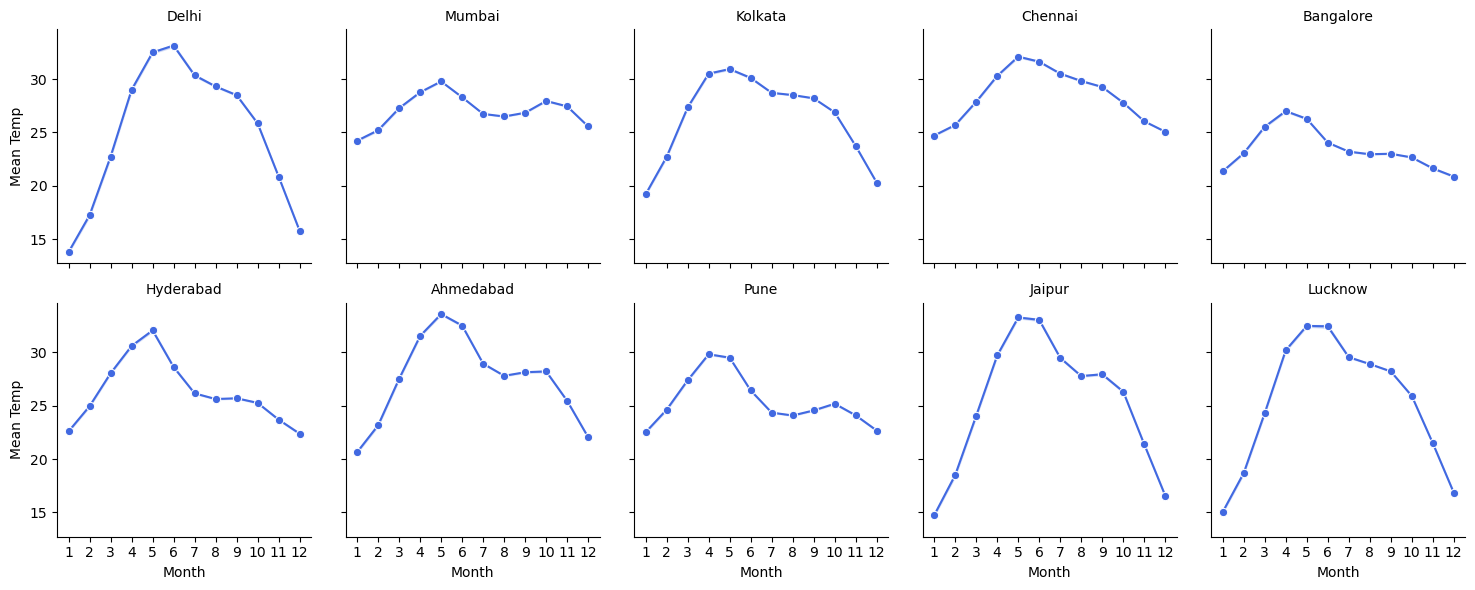

In [103]:
g = sns.FacetGrid(df, col="city", col_wrap=5, height=3, sharey=True)
g.map(sns.lineplot, "month", 'mean_temp_monthly_avg', marker="o", color="royalblue")

# Adjust formatting
g.set_axis_labels("Month", "Mean Temp")
g.set_titles("{col_name}")
g.set(xticks=range(1, 13))
plt.show()

In [104]:
g.figure.savefig(os.path.join(path, 'visualizations', 'avg_monthly_mean_temp_allcities.png'))

#### Observations

Bangalore, Chennai, Hyderabad and Mumbai show the least seasonal temperature variation, along with the highest minimum mean temperatures. This is likely due to the tropical and, in the case of Chennai and Mumbai, coastal climate of these cities. 

Jaipur, Delhi and Lucknow show the greatest seasonal variation in mean temperature, as well as the lowest temperatures in winter. This is likely due to the arid, subtropical climate in these cities. 

April-May appear to be the warmest months for all cities.

#### Average Precipitation by Month, by City

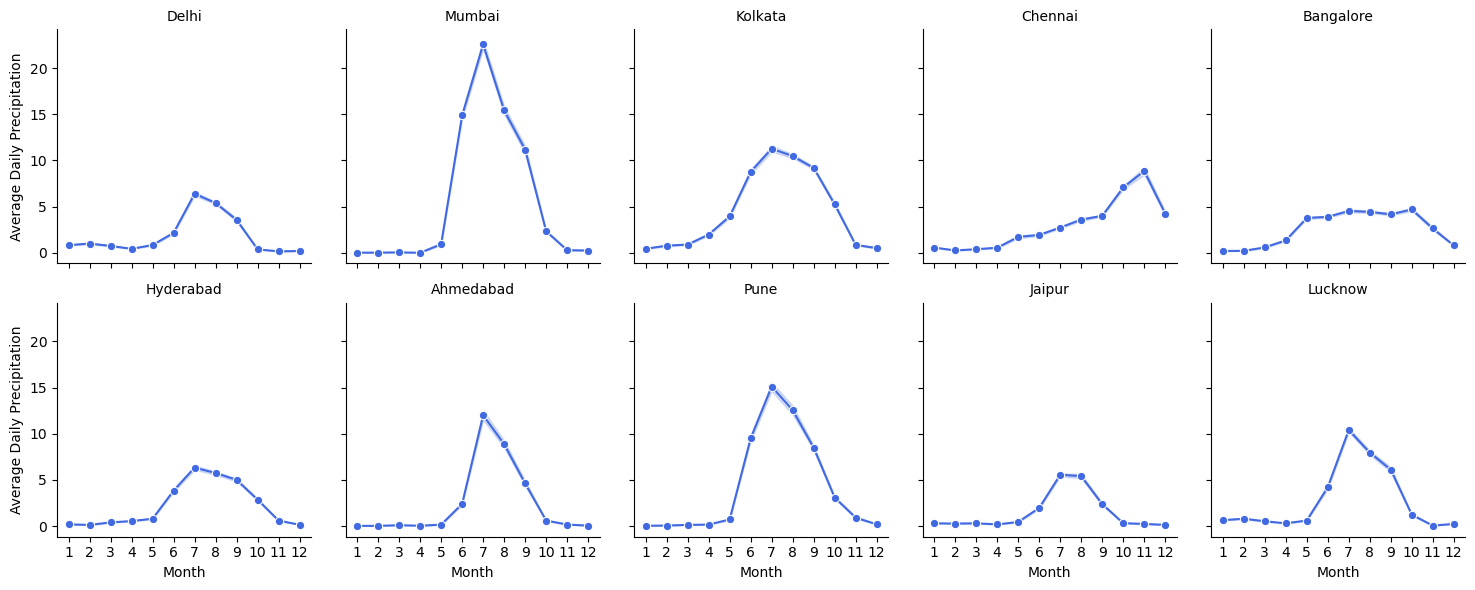

In [107]:
g = sns.FacetGrid(df, col="city", col_wrap=5, height=3, sharey=True)
g.map(sns.lineplot, "month", 'precipitation_monthly_avg', marker="o", color="royalblue")

# Adjust formatting
g.set_axis_labels("Month", "Average Daily Precipitation")
g.set_titles("{col_name}")
g.set(xticks=range(1, 13))
plt.show()

In [108]:
g.figure.savefig(os.path.join(path, 'visualizations', 'avg_monthly_precipitation_allcities.png'))

#### Observations

All cities show a distinct period of increased precipitation within the year. 

Mumbai receives the highest levels of precipitation among all cities. Delhi, Jaipur, Bangalore and Hyderabad receive the lowest levels (again, possibly due to those cities having a drier climate)

For the majority of cities, precipitation sharply increases around June, peaks in July and drops between September and October. 

Chennai displays a slight increase in precipitation around June, similar to nearby cities (Bangalore and Hyderabad). However, there is a later peak in precipitation levels in October and November when the rest of the cities experience lower levels. This is likely due to Chennai being particularly prone to cyclones occurring during that time of year. 

#### Comparing Average Monthly Mean Temp and Average Monthly Perceived Mean Temp, by City

In [111]:
melted_df = df.melt(
    id_vars=["city", "month"],
    value_vars=["mean_temp_monthly_avg", "apparent_mean_temp_monthly_avg"],
    var_name="Temp_Type",
    value_name="Daily_Mean_Temp",
)

In [112]:
melted_df["Temp_Type"] = melted_df["Temp_Type"].replace(
    {"mean_temp_monthly_avg": "Actual Temp", "apparent_mean_temp_monthly_avg": "Perceived Temp"}
)

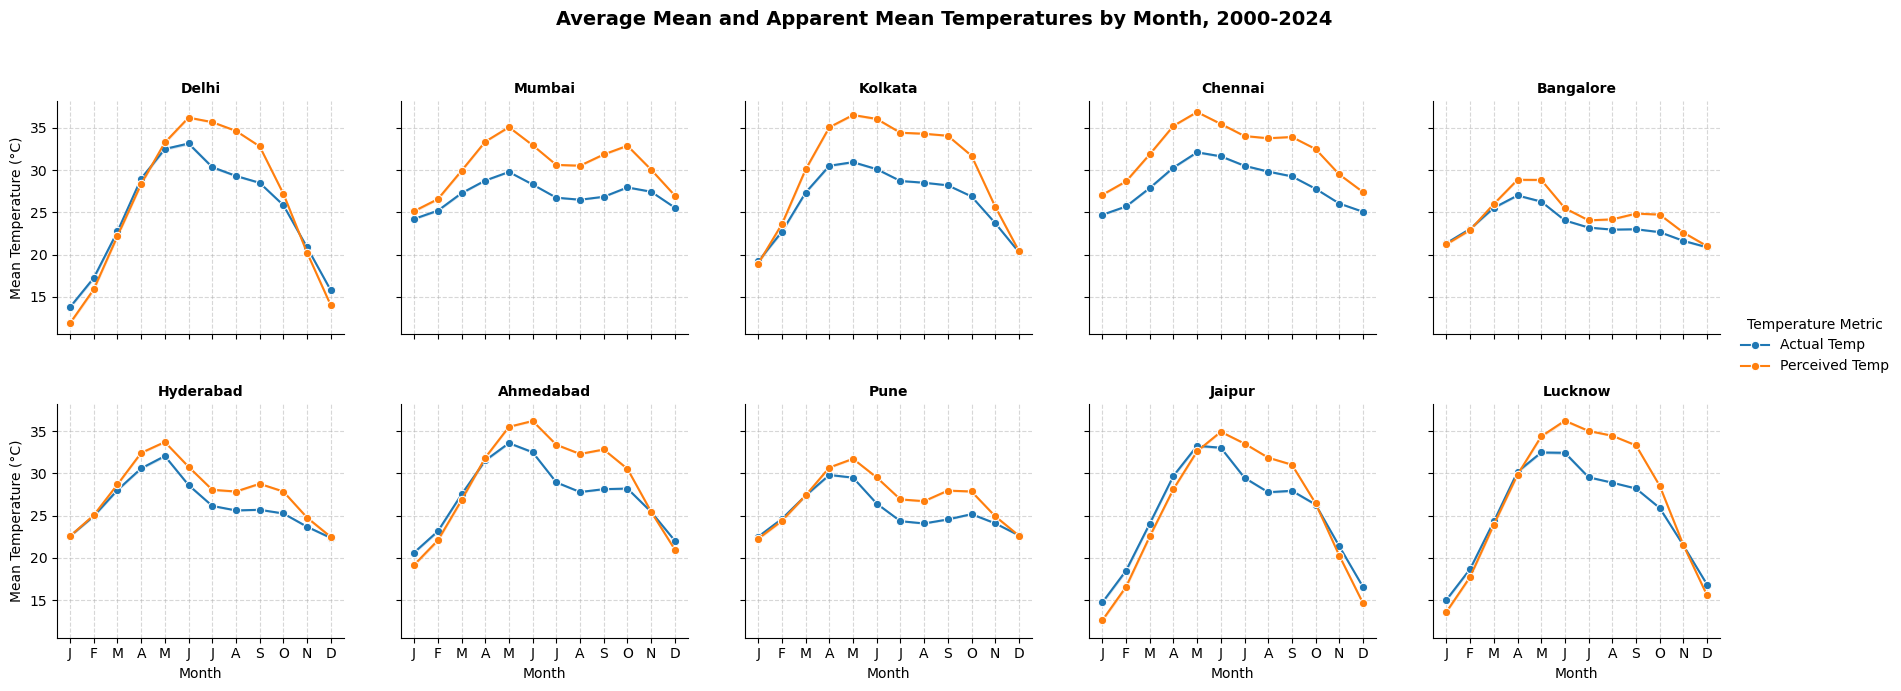

In [113]:
g = sns.FacetGrid(
    melted_df,
    col="city",
    col_wrap=5,
    height=3.5,
    sharey=True,  # Keeps the temperature scale identical across cities for easy comparison
)
g.map_dataframe(
    sns.lineplot,
    x="month",
    y="Daily_Mean_Temp",
    hue="Temp_Type",
    marker="o",
    palette=["#1f77b4", "#ff7f0e"],  # Blue for actual, Orange for perceived
)
g.set_axis_labels("Month", "Mean Temperature (°C)")
g.set_titles("{col_name}", weight="bold")
g.set(xticks=range(1, 13))
month_labels = [
    "J",
    "F",
    "M",
    "A",
    "M",
    "J",
    "J",
    "A",
    "S",
    "O",
    "N",
    "D",
]
for ax in g.axes.flat:
    ax.set_xticklabels(month_labels)
    ax.grid(True, linestyle="--", alpha=0.5)
g.add_legend(title="Temperature Metric")
plt.subplots_adjust(top=0.85, wspace=0.2, hspace=0.3)
g.figure.suptitle(
    "Average Mean and Apparent Mean Temperatures by Month, 2000-2024",
    fontsize=14,
    weight="bold",
)

plt.show()

In [114]:
g.figure.savefig(os.path.join(path, 'visualizations', 'avg_monthly_mean_apparentmean_temps_allcities.png'))

#### Observations

Delhi and Lucknow display very similar seasonal variations in actual and perceived temperature, likely due to the two cities being geographically close. 

Mumbai, Kolkata and Chennai show higher perceived temperatures throughout most of the year, possibly due to the coastal location of these three cities. 

Jaipur shows slightly higher actual temperatures during the winter months, with Ahmedabad, Delhi and Lucknow displaying similar patterns. This may be due to the arid climate of these cities, which can cause low temperatures to feel colder than they are.

#### Comparing Minimum and Maximum Recorded Temperatures by Month, by City

In [117]:
melted_df2 = df.melt(
    id_vars=["city", "month"],
    value_vars=["min_temp_monthly_avg", "max_temp_monthly_avg"],
    var_name="Temp_Type",
    value_name="Temp",
)

In [118]:
melted_df2["Temp_Type"] = melted_df2["Temp_Type"].replace(
    {"min_temp_monthly_avg": "Daily Minimum (Monthly Avg)", "max_temp_monthly_avg": "Daily Maximum (Monthly Avg)"}
)

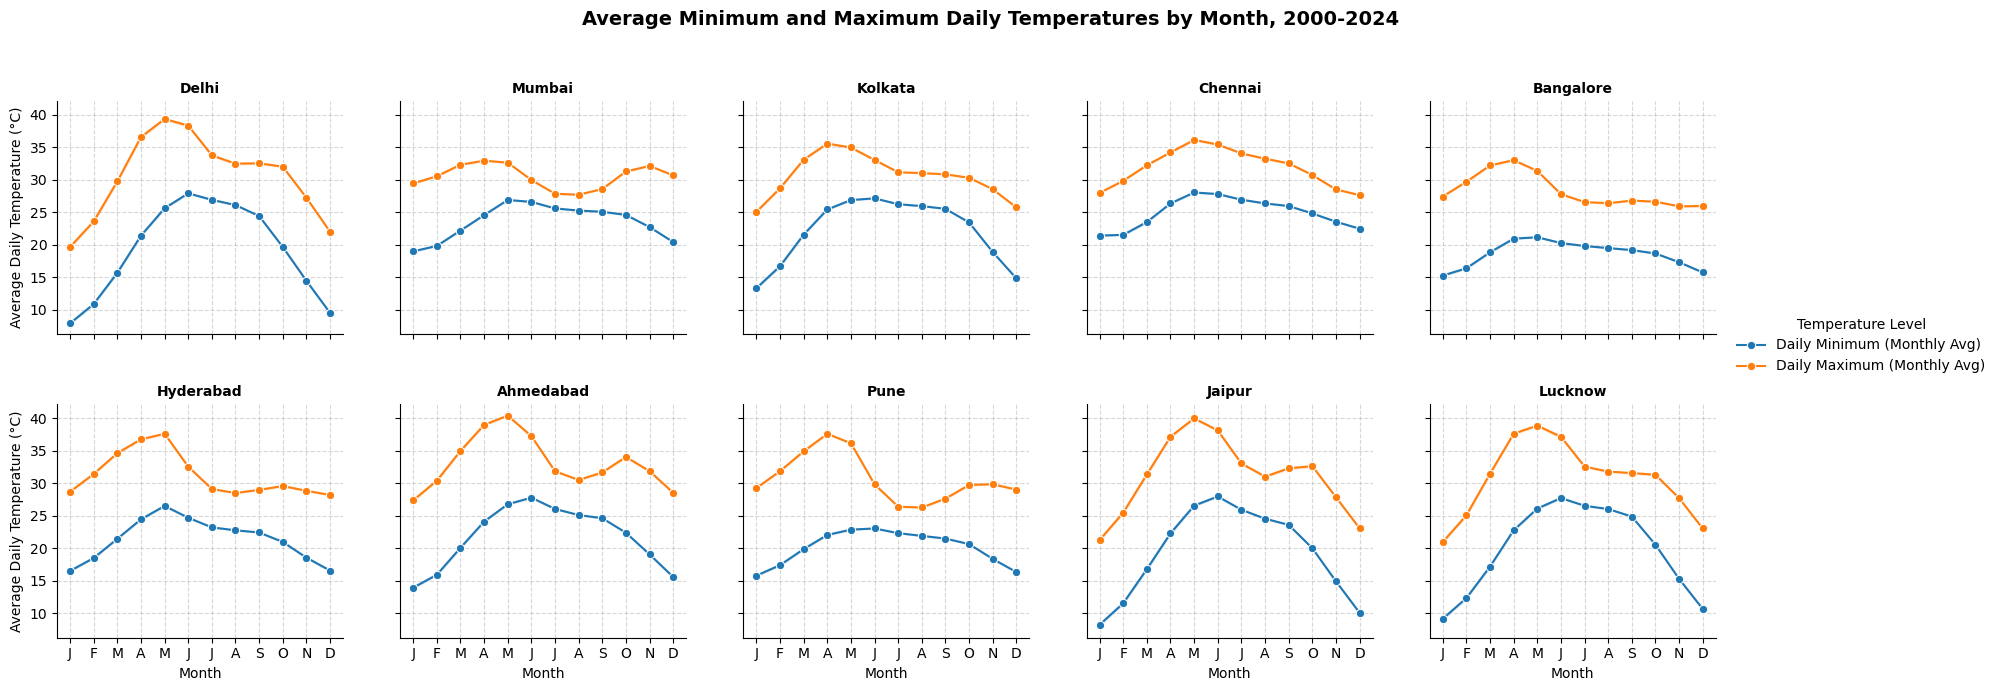

In [119]:
g = sns.FacetGrid(
    melted_df2,
    col="city",
    col_wrap=5,
    height=3.5,
    sharey=True,  # Keeps the temperature scale identical across cities for easy comparison
)
g.map_dataframe(
    sns.lineplot,
    x="month",
    y="Temp",
    hue="Temp_Type",
    marker="o",
    palette=["#1f77b4", "#ff7f0e"],  # Blue for actual, Orange for perceived
)
g.set_axis_labels("Month", 'Average Daily Temperature (°C)')
g.set_titles("{col_name}", weight="bold")
g.set(xticks=range(1, 13))
month_labels = [
    "J",
    "F",
    "M",
    "A",
    "M",
    "J",
    "J",
    "A",
    "S",
    "O",
    "N",
    "D",
]
for ax in g.axes.flat:
    ax.set_xticklabels(month_labels)
    ax.grid(True, linestyle="--", alpha=0.5)
g.add_legend(title="Temperature Level")
plt.subplots_adjust(top=0.85, wspace=0.2, hspace=0.3)
g.figure.suptitle(
    "Average Minimum and Maximum Daily Temperatures by Month, 2000-2024",
    fontsize=14,
    weight="bold",
)

plt.show()

In [120]:
g.figure.savefig(os.path.join(path, 'visualizations', 'avg_monthly_minmax_temps_allcities.png'))

#### Observations

The daily temperature range is narrowest when precipitation levels are at their highest.

The first 3 months of the year have the widest range of daily temperatures, likely due to the dry season.

#### Average Daily Mean Temp vs Average Perceived Daily Mean Temp across all cities, by year

In [123]:
melted_years = df.melt(
    id_vars=["year", "month"],
    value_vars=["mean_temp_monthly_avg", "apparent_mean_temp_monthly_avg"],
    var_name="Temp_Type",
    value_name="Mean_Temp",
)

In [124]:
melted_years["Temp_Type"] = melted_years["Temp_Type"].replace(
    {"mean_temp_monthly_avg": "Actual Temp", "apparent_mean_temp_monthly_avg": "Perceived Temp"}
)

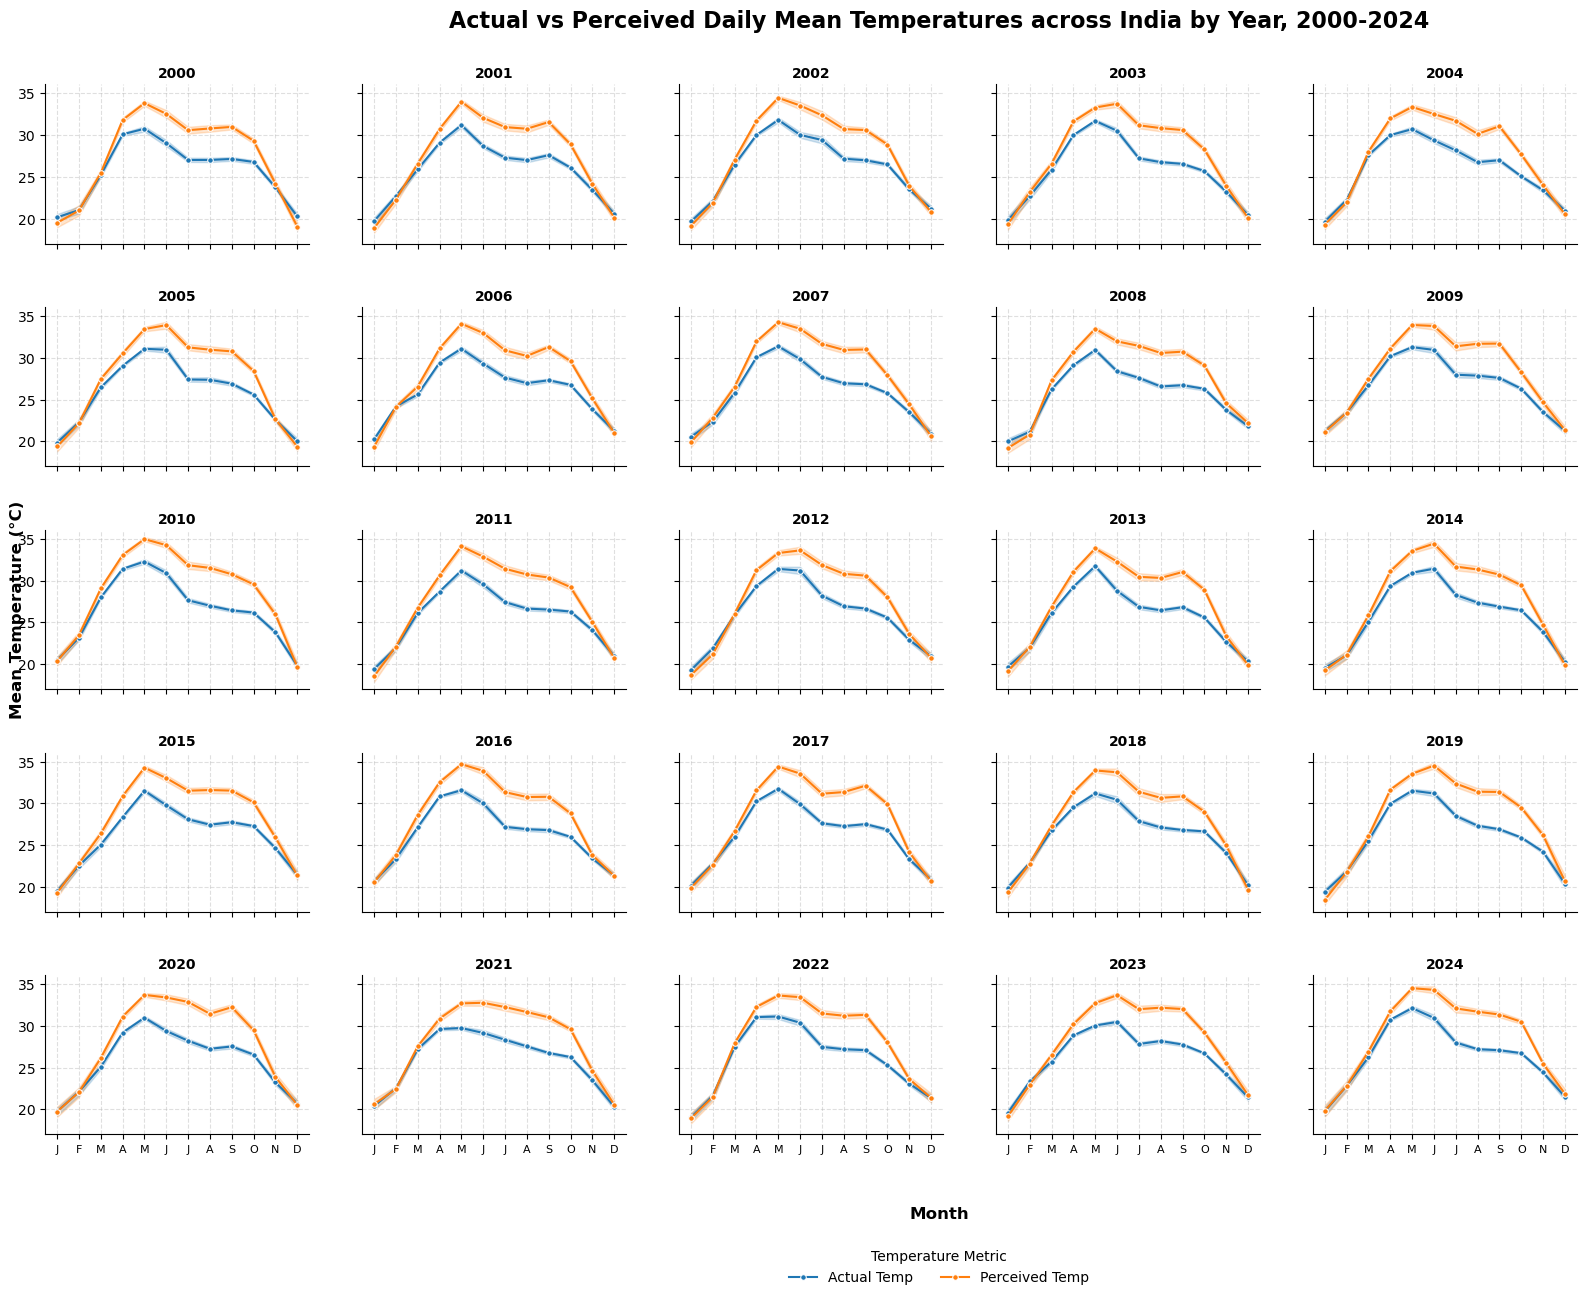

In [125]:
g = sns.FacetGrid(
    melted_years,
    col="year",
    col_wrap=5,  # 5 plots per row x 5 rows = 25 years
    height=2.5,
    aspect=1.3,
    sharey=True,  # Keeps temperature scale consistent across all years
)
g.map_dataframe(
    sns.lineplot,
    x="month",
    y="Mean_Temp",
    hue="Temp_Type",
    marker="o",
    markersize=4,
    palette=["#1f77b4", "#ff7f0e"],  # Blue for actual, Orange for perceived
)
g.set_axis_labels("", "")  # Clear individual inner labels to reduce clutter
g.set_titles("{col_name}", weight="bold", pad=5)
g.set(xticks=range(1, 13))
month_letters = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
for ax in g.axes.flat:
    ax.set_xticklabels(month_letters, fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)
g.add_legend(title="Temperature Metric", loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=2)
g.figure.subplots_adjust(top=0.92, bottom=0.08, wspace=0.2, hspace=0.4)
g.figure.supxlabel("Month", fontsize=12, weight="bold")
g.figure.supylabel("Mean Temperature (°C)", fontsize=12, weight="bold")
g.figure.suptitle(
    "Actual vs Perceived Daily Mean Temperatures across India by Year, 2000-2024",
    fontsize=16,
    weight="bold",
)

plt.show()

In [126]:
g.figure.savefig(os.path.join(path, 'visualizations', 'avg_monthly_minmax_allyears.png'))

### Average Daily Minimum and Maximum Temps Across India, 2000-2024

In [128]:
melted_minmax = df.melt(
    id_vars='month_year',
    value_vars=["min_temp_monthly_avg", "max_temp_monthly_avg"],
    var_name="Temp_Type",
    value_name="Mean_Temp",
)

In [129]:
melted_minmax["Temp_Type"] = melted_minmax["Temp_Type"].replace(
    {"min_temp_monthly_avg": "Daily Minimum", "max_temp_monthly_avg": "Daily Maximum"}
)

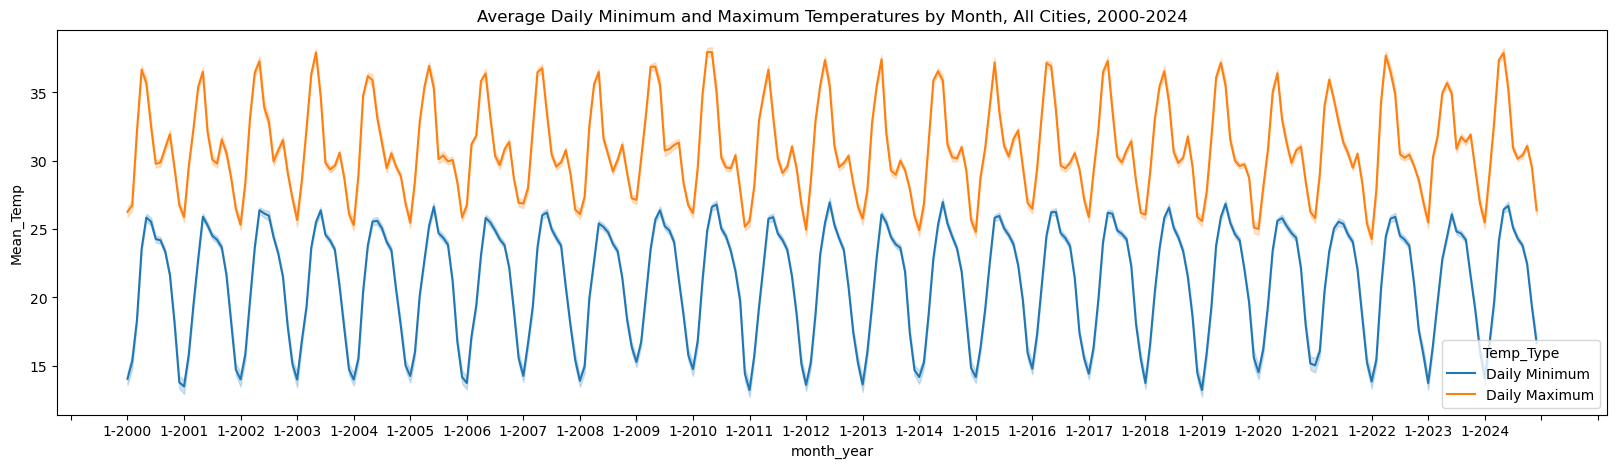

In [130]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax, x='month_year', y='Mean_Temp', hue='Temp_Type')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Average Daily Minimum and Maximum Temperatures by Month, All Cities, 2000-2024')
plt.show()

In [134]:
fig.savefig(os.path.join(path, 'visualizations', 'avg_monthly_minmax_temps_lineplot.png'))

### Average Daily Mean and Perceived Daily Mean Temperatures across India, 2000-2024

In [129]:
melted_temps = df.melt(
    id_vars='month_year',
    value_vars=["mean_temp_monthly_avg", "apparent_mean_temp_monthly_avg"],
    var_name="Temp_Type",
    value_name="Mean_Temp",
)

In [130]:
melted_temps["Temp_Type"] = melted_temps["Temp_Type"].replace(
    {"mean_temp_monthly_avg": "Daily Mean Temp (C)", "apparent_mean_temp_monthly_avg": "Perceived Daily Mean Temp (C)"}
)

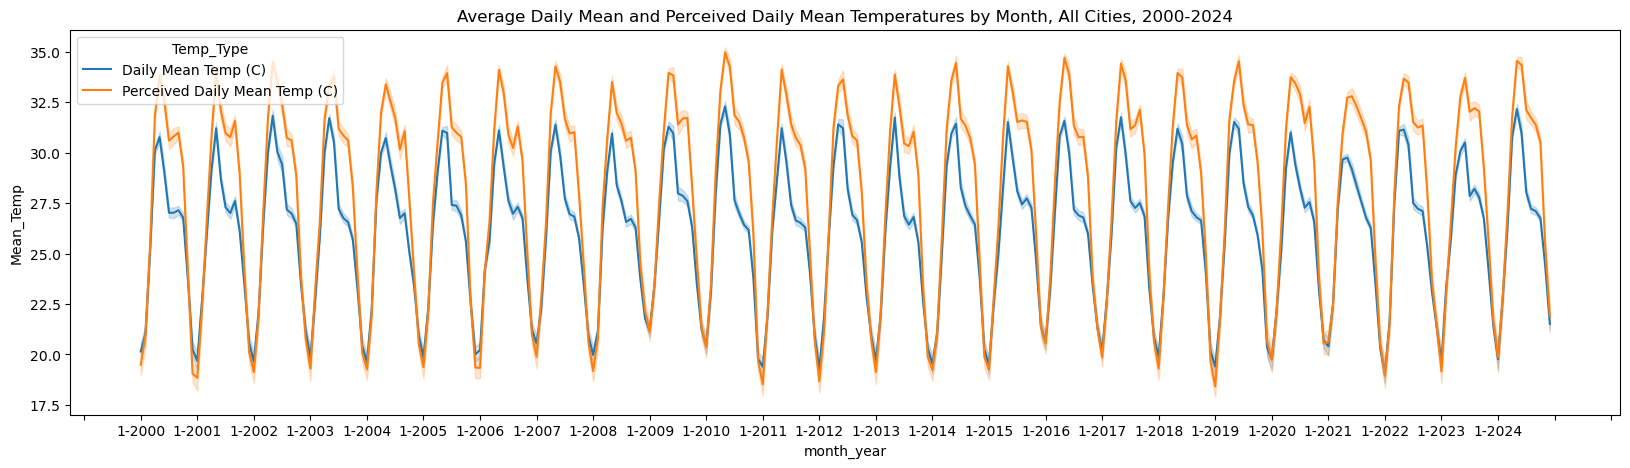

In [131]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_temps, x='month_year', y='Mean_Temp', hue='Temp_Type')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Average Daily Mean and Perceived Daily Mean Temperatures by Month, All Cities, 2000-2024')
plt.show()

In [136]:
fig.savefig(os.path.join(path, 'visualizations', 'avg_monthly_real_perceived_temps_lineplot.png'))

#### Observations

2010-2011 showed the greatest variation in mean temperatures, both real and perceived.

All years show a similar pattern of perceived temperature being higher in the late summer/early fall months.

Some years (around half of them) show an increase in mean temperatures in the fall months. This increase is more pronounced in some years (2001, 2004, 2006, 2013, 2017 and 2020). The increase in perceived temperature is sharper in these years than the increase in actual temperature at the same time. 

#### Precipitation vs Rain levels, 2000-2024

This will show how overall precipitation levels differ (if at all) from rain levels throughout each year between 2000 and 2024

In [134]:
melted_prec = df.melt(
    id_vars='month_year',
    value_vars=['precipitation_monthly_avg', 'rain_monthly_avg'],
    var_name='precipitation_type',
    value_name='precipitation_level',
)

In [135]:
melted_prec['precipitation_type'] = melted_prec['precipitation_type'].replace(
    {'precipitation_monthly_avg': 'Average Daily Precipitation', 'rain_monthly_avg': 'Average Daily Rain'}
)

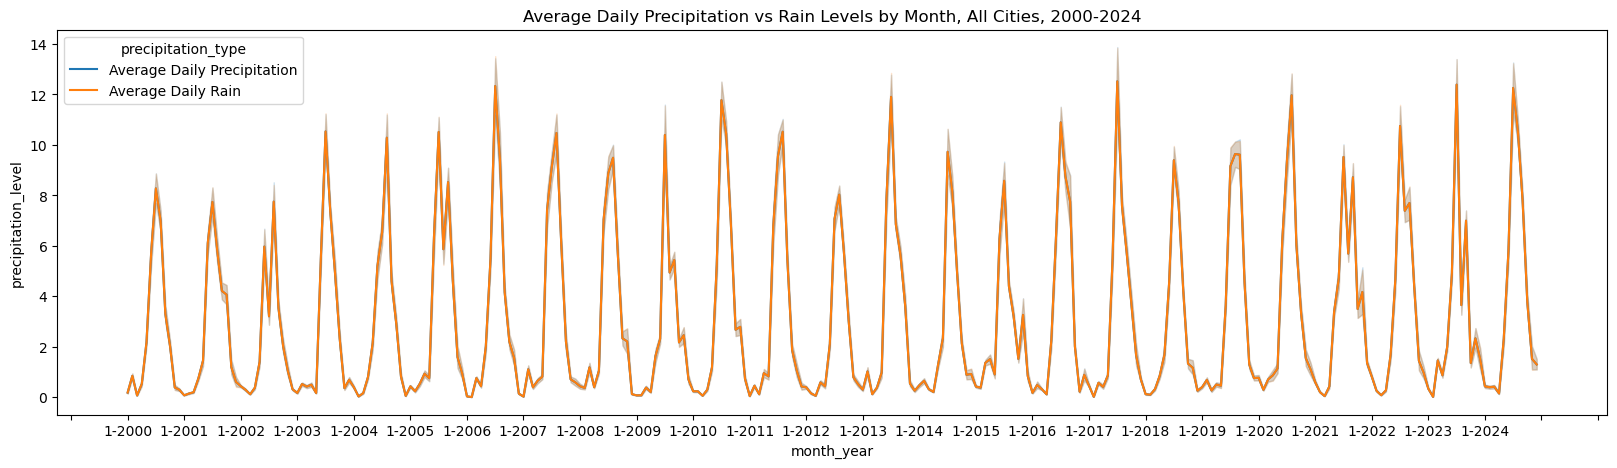

In [136]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_prec, x='month_year', y='precipitation_level', hue='precipitation_type')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Average Daily Precipitation vs Rain Levels by Month, All Cities, 2000-2024')
plt.show()

In [138]:
fig.savefig(os.path.join(path, 'visualizations', 'avg_monthly_rain_lineplot.png'))

#### Observations

Rain and Total Precipitation levels are almost identical, likely due to other forms of precipitation (snow, sleet, etc) not being common in these cities. 

2006 and 2017 recorded the highest levels of precipitation in the summer months. 

2001-2003, 2012 and 2015 showed the lowest levels of precipitation.

#### Average Daily Wind and Wind Gust Speeds, All Cities, 2000-2024

In [139]:
melted_wind = df.melt(
    id_vars='month_year',
    value_vars=['max_wind_monthly_avg', 'max_windgusts_monthly_avg'],
    var_name='wind_gusts',
    value_name='wind_speed',
)

In [140]:
melted_wind['wind_gusts'] = melted_wind['wind_gusts'].replace(
    {'max_wind_monthly_avg': 'Maximum Daily Wind Speed (km/h)', 'max_windgusts_monthly_avg': 'Maximum Daily Wind Gusts (km/h)'}
)

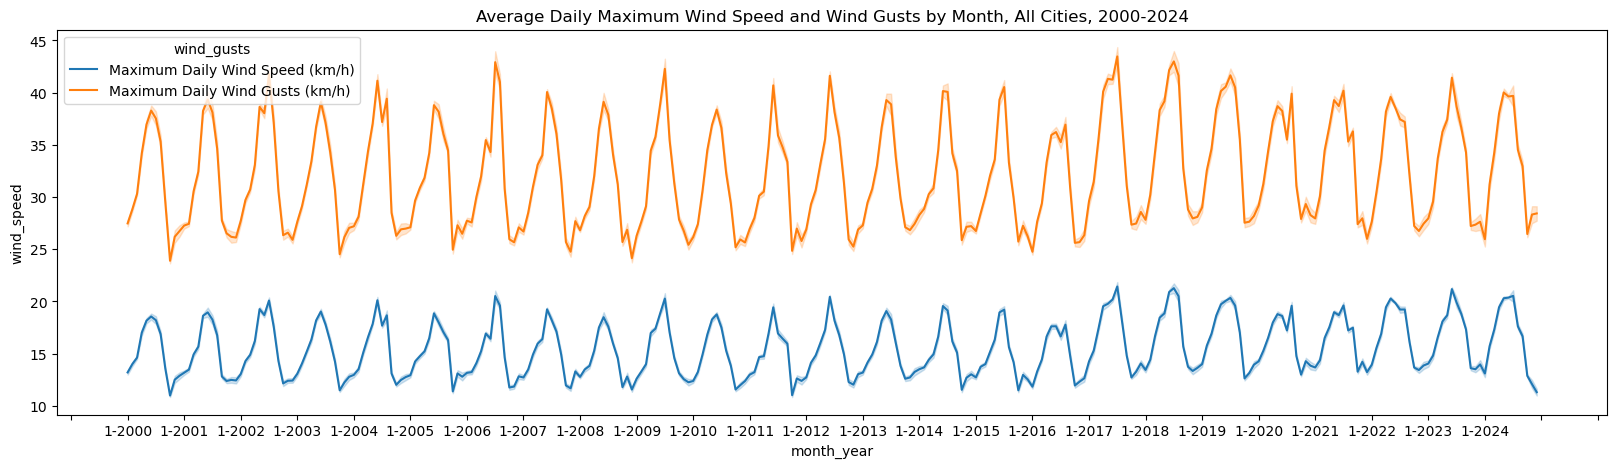

In [141]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_wind, x='month_year', y='wind_speed', hue='wind_gusts')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Average Daily Maximum Wind Speed and Wind Gusts by Month, All Cities, 2000-2024')
plt.show()

In [140]:
fig.savefig(os.path.join(path, 'visualizations', 'avg_monthly_wind_lineplot.png'))

#### Average Daily Wind Speed and Wind Gusts, 2000-2024, By City

In [143]:
melted_wind2 = df.melt(
    id_vars=['city', 'month'],
    value_vars=['max_wind_monthly_avg', 'max_windgusts_monthly_avg'],
    var_name='wind_gusts',
    value_name='wind_speed',
)

In [144]:
melted_wind2['wind_gusts'] = melted_wind2['wind_gusts'].replace(
    {'max_wind_monthly_avg': 'Maximum Daily Wind Speed (km/h)', 'max_windgusts_monthly_avg': 'Maximum Daily Wind Gusts (km/h)'}
)

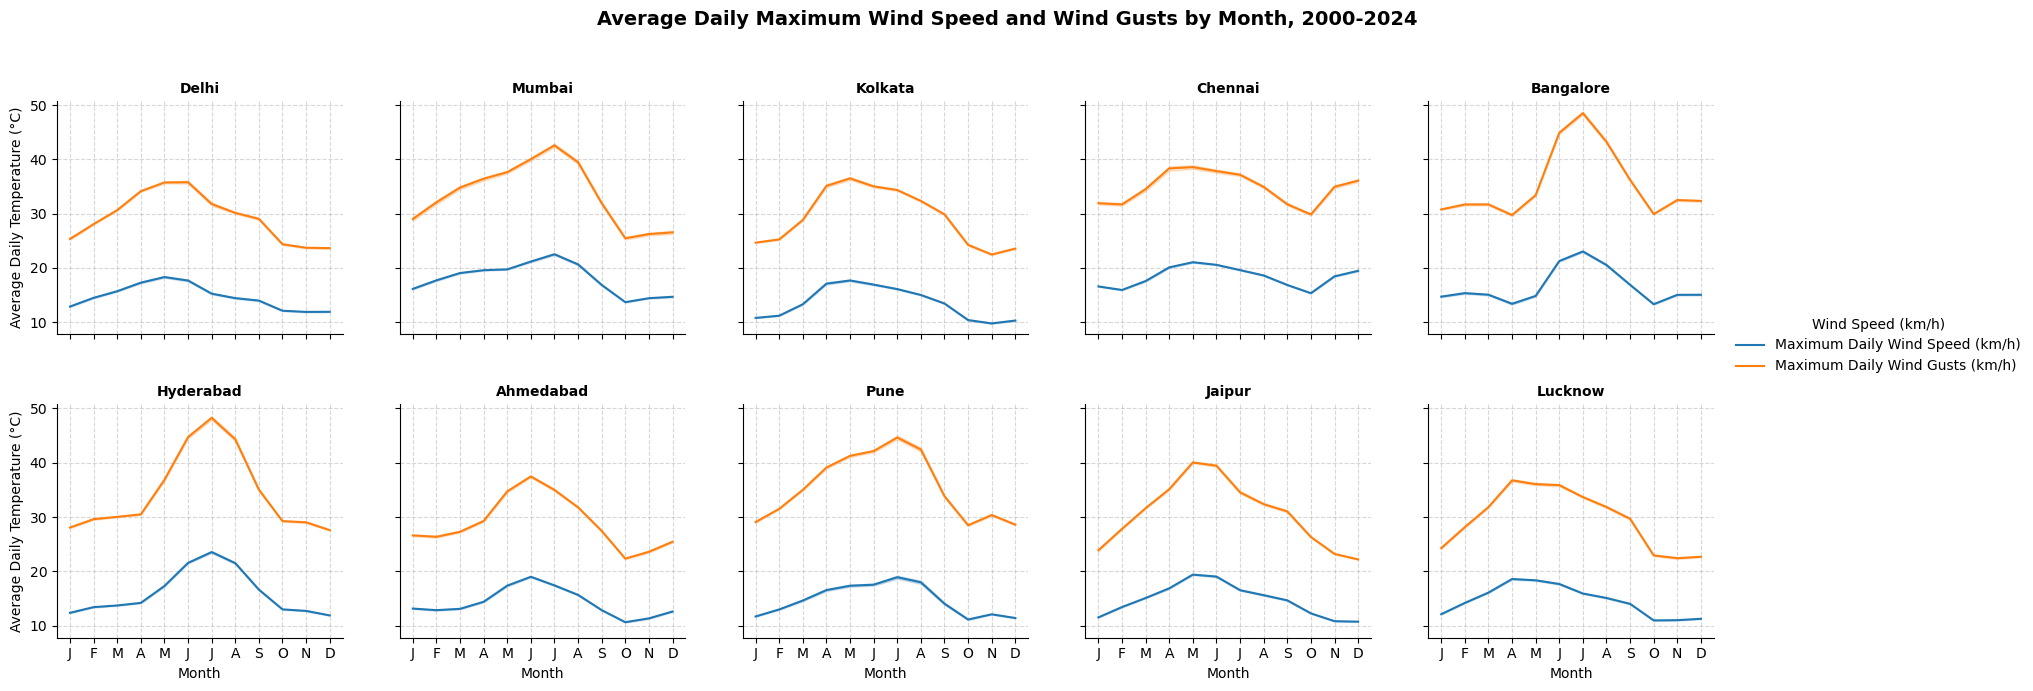

In [145]:
g = sns.FacetGrid(
    melted_wind2,
    col='city',
    col_wrap=5,
    height=3.5,
    sharey=True, 
)
g.map_dataframe(
    sns.lineplot,
    x='month',
    y='wind_speed',
    hue='wind_gusts',
    palette=["#1f77b4", "#ff7f0e"],  # Blue for actual, Orange for perceived
)
g.set_axis_labels("Month", 'Average Daily Temperature (°C)')
g.set_titles("{col_name}", weight="bold")
g.set(xticks=range(1, 13))
month_labels = [
    "J",
    "F",
    "M",
    "A",
    "M",
    "J",
    "J",
    "A",
    "S",
    "O",
    "N",
    "D",
]
for ax in g.axes.flat:
    ax.set_xticklabels(month_labels)
    ax.grid(True, linestyle="--", alpha=0.5)
g.add_legend(title="Wind Speed (km/h)")
plt.subplots_adjust(top=0.85, wspace=0.2, hspace=0.3)
g.figure.suptitle(
    "Average Daily Maximum Wind Speed and Wind Gusts by Month, 2000-2024",
    fontsize=14,
    weight="bold",
)

plt.show()

In [142]:
g.savefig(os.path.join(path, 'visualizations', 'avg_monthly_wind_by_city_lineplot.png'))